## MULTIPLE LINEAR REGRESSION COMPARISON
### Objective:
- Identify dependent and independent variables
- Find out high co-related independent varaibles and remove them (if any) before analysis
- Perform Multi-Linear regression analysis for different models 
    Model1 : Electrical Variables
    Model 2 : Electrical + Time Variables
    Model 3 : Electrical + Time + Season Variables
    Target: Global_active_power
- Select the model that performs better on results obtained from all model analysis

In [21]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

import seaborn as sns
import matplotlib.pyplot as plt

print("Imported all required libraries...")

Imported all required libraries...


In [22]:
# ============================================================
# 1. LOAD DATA
# ============================================================

PROCESSED_PATH = os.path.join('..', 'data', 'processed')
FIGURES_PATH = os.path.join('..', 'outputs', 'figures')

df = pd.read_pickle(os.path.join(PROCESSED_PATH, 'df_cleaned.pkl'))

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head())

Data loaded: 2,049,280 rows × 20 columns
             datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                4.850                  0.436   233.63   
2 2006-12-16 17:26:00                4.850                  0.478   233.29   
3 2006-12-16 17:27:00                4.850                  0.478   233.74   
4 2006-12-16 17:28:00                3.666                  0.478   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  year  \
0              18.4             0.0             1.0            17.0  2006   
1              20.6             0.0             1.0            16.0  2006   
2              20.6             0.0             2.0            17.0  2006   
3              20.6             0.0             1.0            17.0  2006   
4              15.8             0.0             1.0            17.0  2006   

   month  day  hour  minute

In [23]:
# ============================================================
# 2. NUMERIC CONVERSION
# ============================================================

numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# ------------------------------------------------------------
# Cyclical Encoding
# ------------------------------------------------------------

df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

# One-hot encoding
season_dummies = pd.get_dummies(
    df["season"],
    drop_first=True,
    dtype=int
)

df = pd.concat(
    [df, season_dummies],
    axis=1
)

print(df.head())

             datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                4.850                  0.436   233.63   
2 2006-12-16 17:26:00                4.850                  0.478   233.29   
3 2006-12-16 17:27:00                4.850                  0.478   233.74   
4 2006-12-16 17:28:00                3.666                  0.478   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  year  \
0              18.4             0.0             1.0            17.0  2006   
1              20.6             0.0             1.0            16.0  2006   
2              20.6             0.0             2.0            17.0  2006   
3              20.6             0.0             1.0            17.0  2006   
4              15.8             0.0             1.0            17.0  2006   

   month  ...  week_of_year  quarter  is_weekend  time_of_day  seaso

In [24]:
# ============================================================
# 6. CLEAN DATA
# ============================================================

df = df.dropna()

print(
    "Shape After Cleaning:",
    df.shape
)

# ============================================================
# FEATURE SETS
# ============================================================

target = "Global_active_power"

# ------------------------------------------------------------
# MODEL 1
# ------------------------------------------------------------

features_model1 = [
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

# ------------------------------------------------------------
# MODEL 2
# ------------------------------------------------------------

features_model2 = (
    features_model1 +
    [
        "hour_sin",
        "hour_cos",
        "is_weekend"
    ]
)

# ------------------------------------------------------------
# MODEL 3
# ------------------------------------------------------------

features_model3 = (
    features_model2 +
    [
        "Spring",
        "Summer",
        "Winter"
    ]
)


Shape After Cleaning: (2049280, 25)


In [25]:
# ============================================================
# FUNCTION: VIF CHECK
# ============================================================
def calculate_vif(X):

    # Make a copy
    X = X.copy()

    # Convert all predictors to numeric
    X = X.astype(float)

    vif_df = pd.DataFrame()

    vif_df["Variable"] = X.columns

    vif_df["VIF"] = [
        variance_inflation_factor(
            X.values,
            i
        )
        for i in range(X.shape[1])
    ]

    return vif_df


In [30]:
# ============================================================
# FUNCTION: MODEL FITTING
# ============================================================

def evaluate_model(
    data,
    features,
    target,
    model_name
):

    print("\n")
    print("="*60)
    print(model_name)
    print("="*60)

    X = data[features]
    y = data[target]

    # --------------------------------------------------------
    # Correlation Heatmap
    # --------------------------------------------------------

    plt.figure(figsize=(8,6))

    sns.heatmap(
        X.corr(),
        cmap="coolwarm"
    )

    plt.title(
        f"{model_name} Correlation"
    )
    file_name = f"regression-{model_name}.png"
    plt.savefig(os.path.join(FIGURES_PATH, file_name), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved figure: {os.path.join(FIGURES_PATH, file_name)}")

    # --------------------------------------------------------
    # VIF
    # --------------------------------------------------------

    vif_df = calculate_vif(X)

    print("\nVIF")

    print(
        vif_df.sort_values(
            by="VIF",
            ascending=False
        )
    )

    # --------------------------------------------------------
    # Train Test Split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            random_state=42
        )
    )

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    model = LinearRegression()

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    r2 = r2_score(
        y_test,
        y_pred
    )

    n = len(y_test)

    p = X_test.shape[1]

    adjusted_r2 = 1 - (
        ((1-r2)*(n-1))
        /
        (n-p-1)
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nPerformance")

    print("R² =", round(r2,4))
    print(
        "Adjusted R² =",
        round(adjusted_r2,4)
    )
    print(
        "RMSE =",
        round(rmse,4)
    )
    print(
        "MAE =",
        round(mae,4)
    )

    # --------------------------------------------------------
    # OLS Summary
    # --------------------------------------------------------
    print(X.dtypes)
    X_sm = sm.add_constant(X)

    ols_model = sm.OLS(
        y,
        X_sm
    ).fit()

    print(
        ols_model.summary()
    )

    return {
        "Model": model_name,
        "R2": r2,
        "Adj_R2": adjusted_r2,
        "RMSE": rmse,
        "MAE": mae
    }




Model-1_Electrical


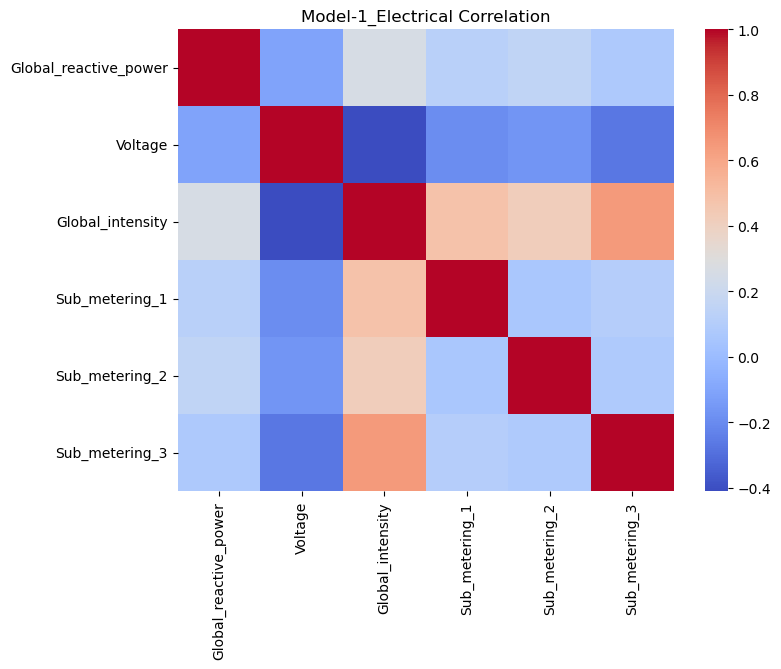

Saved figure: ..\outputs\figures\regression-Model-1_Electrical.png

VIF
                Variable       VIF
2       Global_intensity  7.492582
5         Sub_metering_3  3.402672
1                Voltage  3.139721
0  Global_reactive_power  2.478058
3         Sub_metering_1  1.591030
4         Sub_metering_2  1.485033

Performance
R² = 0.9985
Adjusted R² = 0.9985
RMSE = 0.0397
MAE = 0.0254
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
                             OLS Regression Results                            
Dep. Variable:     Global_active_power   R-squared:                       0.998
Model:                             OLS   Adj. R-squared:                  0.998
Method:                  Least Squares   F-statistic:                 2.216e+08
Date:                 Mon, 15 Jun 2026   Prob (F-statistic):               0.0

In [32]:

# ============================================================
# RUN MODELS
# ============================================================

results = []

results.append(
    evaluate_model(
        df,
        features_model1,
        target,
        "Model-1-Electrical"
    )
)




Model-2-Electrical + Time


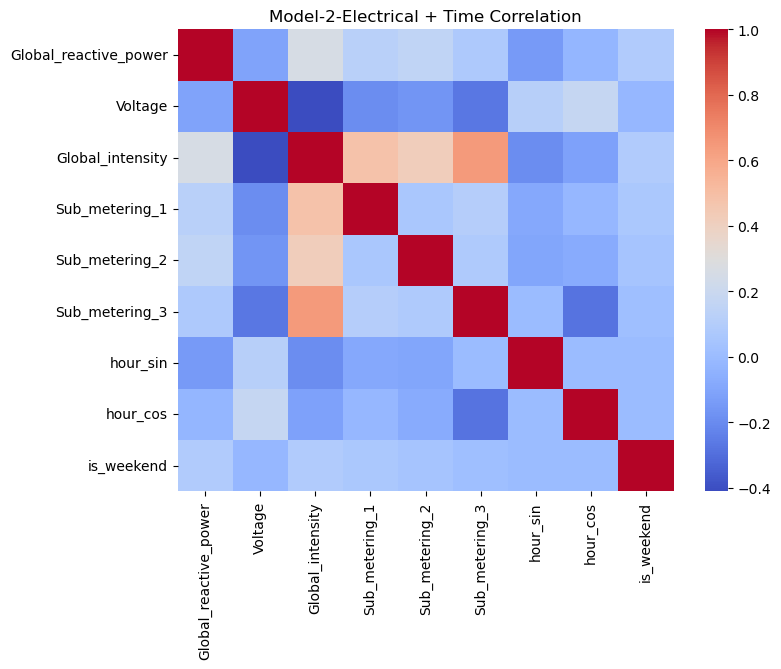

Saved figure: ..\outputs\figures\regression-Model-2-Electrical + Time.png

VIF
                Variable       VIF
2       Global_intensity  8.043096
5         Sub_metering_3  3.854526
1                Voltage  3.477331
0  Global_reactive_power  2.508487
3         Sub_metering_1  1.608352
4         Sub_metering_2  1.513618
8             is_weekend  1.414584
7               hour_cos  1.118997
6               hour_sin  1.080842

Performance
R² = 0.9985
Adjusted R² = 0.9985
RMSE = 0.0396
MAE = 0.0254
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
hour_sin                 float64
hour_cos                 float64
is_weekend                 int64
dtype: object
                             OLS Regression Results                            
Dep. Variable:     Global_active_power   R-squared:                       0.998
Model:                     

In [35]:

results.append(
    evaluate_model(
        df,
        features_model2,
        target,
        "Model-2-Electrical + Time"
    )
)




Model-3-Electrical + Time + Season


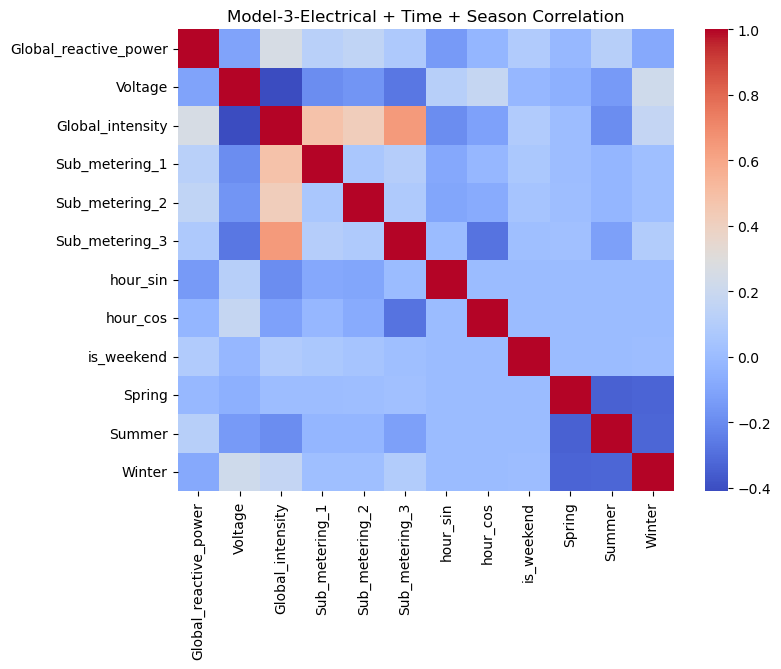

Saved figure: ..\outputs\figures\regression-Model-3-Electrical + Time + Season.png

VIF
                 Variable       VIF
2        Global_intensity  8.702269
1                 Voltage  6.480314
5          Sub_metering_3  3.906553
0   Global_reactive_power  2.617072
10                 Summer  2.090214
9                  Spring  2.021354
11                 Winter  2.016226
3          Sub_metering_1  1.642579
4          Sub_metering_2  1.535420
8              is_weekend  1.414621
7                hour_cos  1.119160
6                hour_sin  1.082847

Performance
R² = 0.9985
Adjusted R² = 0.9985
RMSE = 0.0393
MAE = 0.0252
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
hour_sin                 float64
hour_cos                 float64
is_weekend                 int64
Spring                     int64
Summer                     int64
Winter  

In [34]:
results.append(
    evaluate_model(
        df,
        features_model3,
        target,
        "Model-3-Electrical + Time + Season"
    )
)

In [36]:

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(
    results_df.sort_values(
        by="Adj_R2",
        ascending=False
    )
)



MODEL COMPARISON
                                Model        R2    Adj_R2      RMSE       MAE
2  Model-3-Electrical + Time + Season  0.998515  0.998515  0.039294  0.025208
1             Model-2-Electrical+Time  0.998495  0.998495  0.039556  0.025395
3           Model-2-Electrical + Time  0.998495  0.998495  0.039556  0.025395
0                  Model-1_Electrical  0.998486  0.998486  0.039675  0.025417


### Summary derived from analysis
Three multiple linear regression models were developed to predict household active power consumption. 
1. Model 1 - Used electrical measurements only
2. Model 2 incorporated temporal variables - time_of_day and weekend/weekday
3. Model 3 additionally included seasonal indicators.

All three models achieved extremely high predictive performance, with R² values exceeding 0.998, indicating that more than 99.8% of the variation in Global_active_power was explained by the predictors. This result is expected because the electrical variables are directly related to power consumption according to established electrical principles.

The inclusion of temporal variables produced a modest improvement in predictive accuracy, suggesting that daily and weekly household usage patterns contribute additional explanatory power. The addition of seasonal indicators further improved model performance, indicating that seasonal consumption patterns also influence household electricity usage.

However, the incremental improvements in R², RMSE, and MAE were relatively small. This suggests that electrical measurements are the dominant determinants of active power consumption, while temporal and seasonal variables provide only supplementary predictive information.

Among the three models, Model 3 achieved the highest predictive accuracy and lowest prediction error. Therefore, Model 3 is selected as the preferred model. Nevertheless, Model 2 may be preferred in situations where a simpler model is desired, as it achieves nearly identical performance with fewer predictors.